In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 
import matplotlib as mpl

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive, approx
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [2]:
def draw_loglog_slope(fig, ax, origin, width_inches, slope, inverted=False, color=None, polygon_kwargs=None, label=True, labelcolor=None, label_kwargs=None, zorder=None):
    """
    This function draws slopes or "convergence triangles" into loglog plots.
    @param fig: The figure
    @param ax: The axes object to draw to
    @param origin: The 2D origin (usually lower-left corner) coordinate of the triangle
    @param width_inches: The width in inches of the triangle
    @param slope: The slope of the triangle, i.e. order of convergence
    @param inverted: Whether to mirror the triangle around the origin, i.e. whether 
        it indicates the slope towards the lower left instead of upper right (defaults to false)
    @param color: The color of the of the triangle edges (defaults to default color)
    @param polygon_kwargs: Additional kwargs to the Polygon draw call that creates the slope
    @param label: Whether to enable labeling the slope (defaults to true)
    @param labelcolor: The color of the slope labels (defaults to the edge color)
    @param label_kwargs: Additional kwargs to the Annotation draw call that creates the labels
    @param zorder: The z-order value of the triangle and labels, defaults to a high value
    """

    if polygon_kwargs is None:
        polygon_kwargs = {}
    if label_kwargs is None:
        label_kwargs = {}

    if color is not None:
        polygon_kwargs["color"] = color
    if "linewidth" not in polygon_kwargs:
        polygon_kwargs["linewidth"] = 0.75 * mpl.rcParams["lines.linewidth"]
    if labelcolor is not None:
        label_kwargs["color"] = labelcolor
    if "color" not in label_kwargs:
        label_kwargs["color"] = polygon_kwargs["color"]
    if "fontsize" not in label_kwargs:
        label_kwargs["fontsize"] = 0.75 * mpl.rcParams["font.size"]

    if inverted:
        width_inches = -width_inches
    if zorder is None:
        zorder = 10

    # For more information on coordinate transformations in Matplotlib see
    # https://matplotlib.org/3.1.1/tutorials/advanced/transforms_tutorial.html

    # Convert the origin into figure coordinates in inches
    origin_disp = ax.transData.transform(origin)
    origin_dpi = fig.dpi_scale_trans.inverted().transform(origin_disp)

    # Obtain the top-right corner in data coordinates
    corner_dpi = origin_dpi + width_inches * np.array([1.0, 0.0])
    corner_disp = fig.dpi_scale_trans.transform(corner_dpi)
    corner = ax.transData.inverted().transform(corner_disp)

    (x1, y1) = (origin[0], origin[1])
    x2 = corner[0]

    # The width of the triangle in data coordinates
    width = x2 - x1
    # Compute offset of the slope
    log_offset = y1 / (x1 ** (-slope))

    y2 = log_offset * (x2 ** (-slope))
    height = y2 - y1

    # The vertices of the slope
    a = origin
    b = corner
    c = [x2, y2]

    # Draw the slope triangle
    X = np.array([a, b, c])
    triangle = plt.Polygon(X[:3,:], fill=False, zorder=zorder, **polygon_kwargs)
    ax.add_patch(triangle)

    # Convert vertices into display space
    a_disp = ax.transData.transform(a)
    b_disp = ax.transData.transform(b)
    c_disp = ax.transData.transform(c)

    # Figure out the center of the triangle sides in display space
    bottom_center_disp = a_disp + 0.5 * (b_disp - a_disp)
    bottom_center = ax.transData.inverted().transform(bottom_center_disp)

    right_center_disp = b_disp + 0.5 * (c_disp - b_disp)
    right_center = ax.transData.inverted().transform(right_center_disp)

    # Label alignment depending on inversion parameter
    va_xlabel = "bottom" if not inverted else "top"
    ha_ylabel = "left" if not inverted else "right"

    # Label offset depending on inversion parameter
    offset_xlabel = [0.0, 0.33 * label_kwargs["fontsize"]] if not inverted else [0.0, -0.33 * label_kwargs["fontsize"]]
    offset_ylabel = [0.33 * label_kwargs["fontsize"], 0.0] if not inverted else [-0.33 * label_kwargs["fontsize"], 0.0]

    # Draw the slope labels
    ax.annotate("$1$", bottom_center, xytext=offset_xlabel, textcoords='offset points', ha="center", va=va_xlabel, zorder=zorder, **label_kwargs)
    ax.annotate(f"${slope}$", right_center, xytext=offset_ylabel, textcoords='offset points', ha=ha_ylabel, va="center", zorder=zorder, **label_kwargs)


In [3]:
def Lshape(deg, N, k=1):
    kvs = [2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),),2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.Quad(np.array([[-1,-1],[0,-1],[-1,1],[0,0]]).T),
        geometry.Quad(np.array([[-1,1],[0,0],[1,1],[1,0]]).T)
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    return M

In [4]:
def LshapeAnnulus(deg, N, k=1):
    kvs = 3*[2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4),
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4).rotate_2d(angle=np.pi/4),
        geometry.annulus(r1=1.0, r2=1.5, phi = np.pi/4).rotate_2d(angle=np.pi/4),
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    M.outer_boundaries[0].add((1,(0,0)))
    return M

In [5]:
def cart2pol(x, y):
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(r, phi%(2*np.pi))
def u(x,y):
    r, phi = cart2pol(x,y)
    return r**(2/3)*np.sin(2*phi/3)
def ux(x,y):
    r, phi = cart2pol(x,y)
    return -2./3*r**(-1./3)*np.sin(phi/3)
def uy(x,y):
    r, phi = cart2pol(x,y)
    return 2./3*r**(-1./3)*np.cos(phi/3)

In [ ]:
example=1
if example==0:
    f = 0
    dir_data = {0:u}
    exact = True
elif example==1:
    f = 1
    dir_data = {0:0}
    exact = False

degs = (2,3,5,8)
maxpatches =(5000,4000,4000,3000)
maxiter=(5,5,5,4)
#maxiter=4*(50,)
eps=(1e-5,1e-6,5*1e-8,5*1e-9)
plot=1
uniform=1

R = np.zeros((max(maxiter),len(degs)*5))

for i,deg in enumerate(degs):
    print("#########################################")
    N = deg+1
    if example==0:
        M = Lshape(deg,N,1)
    elif example==1:
        M = LshapeAnnulus(deg,N,1)

    MB = assemble.MultiBasis(M, subspace='C0')
    eta=1.0
    U=[]
    k=0
    while k<maxiter[i]:
        if plot:
            M.plotmesh(figsize=(10,10), knots=1, nodes=50, bwidth=0.01, patch_idx=0)
            plt.axis('off');
            plt.axis('scaled');
            #plt.savefig('/home/wolfman/Pictures/p'+str(deg)+'i'+str(k)+'.png',dpi=100,bbox_inches='tight');
            if example==0:
                if uniform:
                    plt.savefig('/mnt/c/Users/stefa/Pictures/Lshape/p'+str(deg)+'/i'+str(k)+'_uniform.png', bbox_inches='tight',dpi=100)
                    #plt.savefig('/home/wolfman/Pictures/Lshape/p'+str(deg)+'/i'+str(k)+'_uniform.png', bbox_inches='tight',dpi=100)
                else:
                    plt.savefig('/mnt/c/Users/stefa/Pictures/Lshape/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
                    #plt.savefig('/home/wolfman/Pictures/Lshape/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            elif example==1:
                if uniform:
                    plt.savefig('/mnt/c/Users/stefa/Pictures/LshapeQ/p'+str(deg)+'/i'+str(k)+'_uniform.png', bbox_inches='tight',dpi=100)
                    #plt.savefig('/home/wolfman/Pictures/LshapeQ/p'+str(deg)+'/i'+str(k)+'_uniform.png', bbox_inches='tight',dpi=100)
                else:
                    plt.savefig('/mnt/c/Users/stefa/Pictures/LshapeQ/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
                    #plt.savefig('/home/wolfman/Pictures/LshapeQ/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            #plt.show();
            plt.close();
            
        ### SOLVE
        R[k,i*5] = MB.nDofs
        R[k,i*5+1] = MB.nPatches

        dir_bcs = MB.set_fixed_boundary(dir_data, local=False)

        Kh = MB.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)
        Fh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=f)
        LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)

        #uh = LS.complete(pypardiso.spsolve(LS.A,LS.b))
        uh = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

        U.append(uh)
        if exact:
            Mh = MB.assemble_volume("u * v * dx", arity=2, domain_id=0)
            Uh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u)
            u_exact = operators.make_solver(Mh,spd=True)@Uh

            eh = uh - u_exact
            Eerr = np.sqrt(eh@Kh@eh)
            R[k,i*5+2] = Eerr
            
        # MB.plot(uh, mesh=True)
        # plt.show();

        if not uniform:
            err_ind=adaptive.mp_resPois(MB, uh, nu=1, f=f)
            eta = np.linalg.norm(err_ind)
            R[k,i*5+3] = eta
            marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
            marked_patches = {p:None for p in marked_patches}
        
        if exact:
            eh = uh - u_exact
            Eerr = np.sqrt(eh@Kh@eh)
            R[k,i*5+2] = Eerr

            if not uniform:
                R[k,i*5+4] = eta/Eerr

        # print(Eerr)
        print(eta)
        # print(eta/Eerr)

        if not uniform:
            if MB.nPatches + 3*len(marked_patches) >= maxpatches[i]:
                break;

        if eta < eps[i]:
            break;

        if not uniform:
            P = MB.h_refine(h_ref=marked_patches,ref="rs", return_P = not exact, in_subspace=True)
        else:
            P = MB.h_refine(h_ref=-1,ref="rs", return_P = not exact, in_subspace=True)

        if not exact:
            for j in range(len(U)):
                U[j]=P@U[j]
        k+=1
    if not exact:
        P = MB.h_refine(h_ref=-1,ref="rs", return_P = True, in_subspace=True)
        P = MB.p_refine(1, return_P = True, in_subspace=True)@P

        dir_bcs = MB.set_fixed_boundary(dir_data, local=False)
        Kh = MB.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)
        Fh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=f)
        LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        
        u_exact = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

        for j in range(len(U)):
            eh = u_exact - P@U[j]
            Eerr = np.sqrt(eh@Kh@eh)
            R[j,i*5+2] = Eerr
            R[j,i*5+4] = R[j,i*5+3]/Eerr
        
if example==0:
    if uniform:
        np.save('Lshape_uniform',R)
    else:
        np.save('Lshape_adaptive',R)
elif example==1:
    if uniform:
        np.save('LshapeQ_uniform',R)
    else:
        np.save('LshapeQ_adaptive',R)

#########################################
setting up constraints took 0.0015354156494140625 seconds.
Basis setup took 0.001119375228881836 seconds
1.0
setting up constraints took 0.0015201568603515625 seconds.
Basis setup took 0.0010027885437011719 seconds
1.0
setting up constraints took 0.002030611038208008 seconds.
Basis setup took 0.0013380050659179688 seconds
1.0
setting up constraints took 0.002152681350708008 seconds.
Basis setup took 0.0013325214385986328 seconds
1.0
setting up constraints took 0.0018579959869384766 seconds.
Basis setup took 0.0015957355499267578 seconds
1.0
setting up constraints took 0.0024557113647460938 seconds.
Basis setup took 0.001783609390258789 seconds
setting up constraints took 0.005462169647216797 seconds.
Basis setup took 0.004973649978637695 seconds
setting up constraints took 0.01804661750793457 seconds.
Basis setup took 0.012957096099853516 seconds
#########################################
setting up constraints took 0.0015404224395751953 seconds

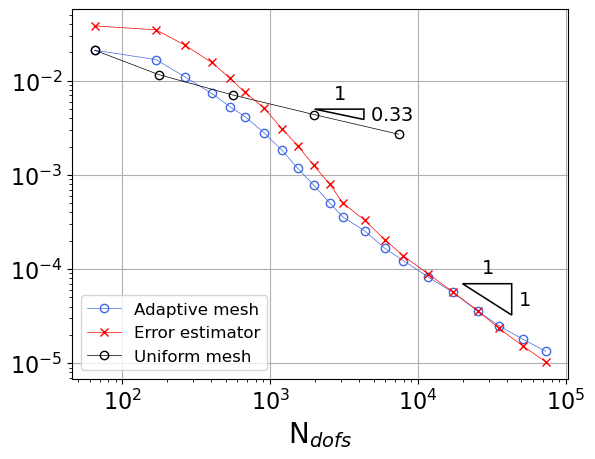

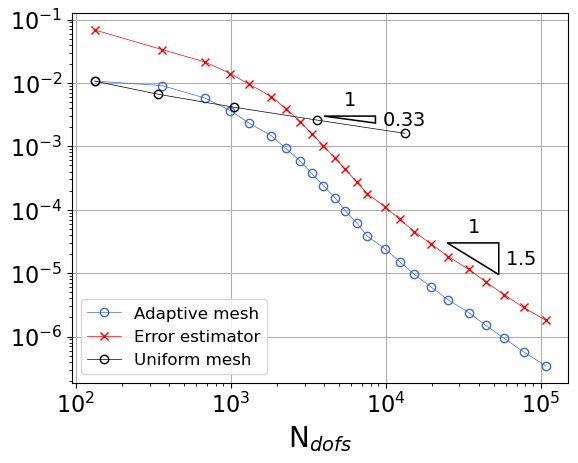

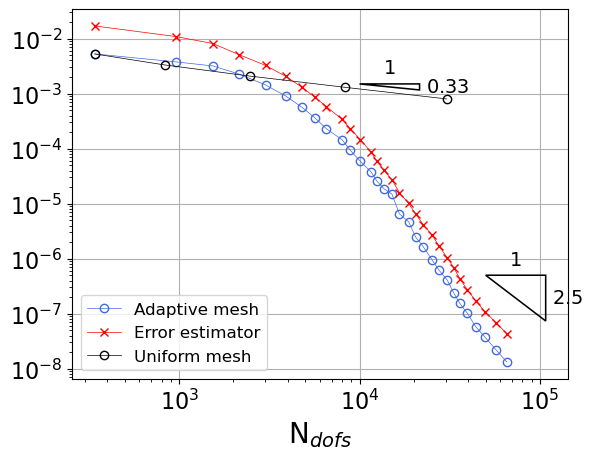

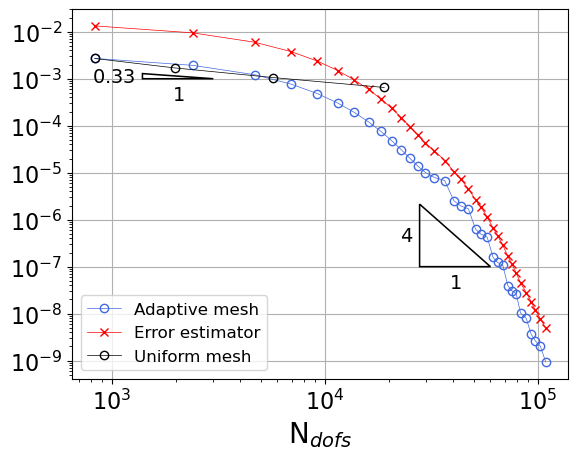

In [8]:
R_a = np.load('LshapeQ_adaptive.npy')
R_u = np.load('LshapeQ_uniform.npy')

numdofs=R_u[:,0]
numdofs_a = R_a[:,0]
Eerr = R_u[:,2]
Eerr_a = R_a[:,2]
pos=((2*1e4,7*1e-5),(2.5*1e4,3*1e-5),(5*1e4,5*1e-7),(6*1e4,1e-7))
pos_u=((2*1e3,5*1e-3),(4*1e3,3*1e-3),(1e4,1.5*1e-3),(3*1e3,1e-3))
w = (1.5,1.5,1.5,1.5)
inv = (False,False,False,True)
for i, deg in enumerate((2,3,5,8)):
    numdofs=R_u[:,i*5+0]
    numdofs_a = R_a[:,i*5+0]
    Eerr = R_u[:,i*5+2]
    Eerr_a = R_a[:,i*5+2]
    Eta = R_a[:,i*5+3]

    numdofs=numdofs[numdofs!=0]
    numdofs_a=numdofs_a[numdofs_a != 0]
    Eerr_a = Eerr_a[Eerr_a!=0]
    Eerr = Eerr[Eerr!=0]
    Eta = Eta[Eta!=0]
    
    fig, ax = plt.subplots()
    plt.loglog(numdofs_a, Eerr_a, 'o-',color='royalblue',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs_a, Eta, 'x-',color='red',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs, Eerr, 'o-',color='black',linewidth=0.5, markerfacecolor='none')
    plt.grid('True');
    ax.tick_params(axis='both', labelsize=16)
    plt.legend(['Adaptive mesh','Error estimator','Uniform mesh'],loc='lower left',prop={'size': 12})
    plt.xlabel("N$_{dofs}$",size=20)
    draw_loglog_slope(fig,ax,pos[i],w[i],slope=int(deg/2) if deg%2==0 else deg/2,inverted=inv[i], color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)
    draw_loglog_slope(fig,ax,pos_u[i],w[i],0.33,inverted=inv[i], color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)

    plt.savefig('LQp'+str(deg)+'n'+str(deg+1)+'H1_cnv.pdf', bbox_inches='tight')
    plt.show()
    

ValueError: x and y must have same first dimension, but have shapes (4,) and (0,)

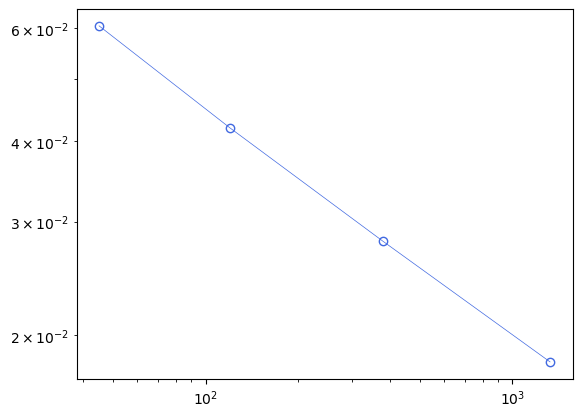

In [10]:
R_a = np.load('Lshape_adaptive.npy')
R_u = np.load('Lshape_uniform.npy')

numdofs=R_u[:,0]
numdofs_a = R[:,0]
Eerr = R_u[:,2]
Eerr_a = R[:,2]
pos=((1e4,5*1e-4),(2.5*1e4,5*1e-5),(2.5*1e4,5*1e-6),(6*1e4,1e-7))
pos_u=((1e4,0.15*1e-1),(1.8*1e4,1e-2),(5*1e4,6*1e-3),(3*1e4,4*1e-3))
for i, deg in enumerate((2,3,5,8)):
    numdofs=R_u[:,i*5+0]
    numdofs_a = R[:,i*5+0]
    Eerr = R_u[:,i*5+2]
    Eerr_a = R[:,i*5+2]
    Eta = R[:,i*5+3]

    numdofs=numdofs[numdofs!=0]
    numdofs_a=numdofs_a[numdofs_a != 0]
    Eerr_a = Eerr_a[Eerr_a!=0]
    Eerr = Eerr[Eerr!=0]
    Eta = Eta[Eta!=0]
    
    fig, ax = plt.subplots()
    plt.loglog(numdofs_a, Eerr_a, 'o-',color='royalblue',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs_a, Eta, 'x-',color='red',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs, Eerr, 'o-',color='black',linewidth=0.5, markerfacecolor='none')
    plt.grid('True');
    ax.tick_params(axis='both', labelsize=16)
    plt.legend(['Adaptive mesh','Error estimator','Uniform mesh'],loc='lower left',prop={'size': 12})
    plt.xlabel("N$_{dofs}$",size=20)
    draw_loglog_slope(fig,ax,pos[i],2,slope=int(deg/2) if deg%2==0 else deg/2,inverted=False, color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)
    draw_loglog_slope(fig,ax,pos_u[i],2,0.33,inverted=False, color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)

    plt.savefig('Lp'+str(deg)+'n'+str(deg+1)+'H1_cnv.pdf', bbox_inches='tight')
    plt.show()
    